In [1]:
# Core Libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Load dataset
df = pd.read_csv("/content/Housing.csv")

# Basic overview
print("Shape:", df.shape)
df.head()


Shape: (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
# Data types
print(df.dtypes)

# Missing values
print("\nMissing Values:\n", df.isnull().sum())

# Statistical summary
df.describe()


price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

Missing Values:
 price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [4]:
# Target variable
y = df['price']

# Features
X = df.drop('price', axis=1)

# Identify categorical & numerical columns
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object']).columns.tolist()

print("Categorical Columns:", cat_cols)
print("Numerical Columns:", num_cols)


Categorical Columns: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']
Numerical Columns: ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']


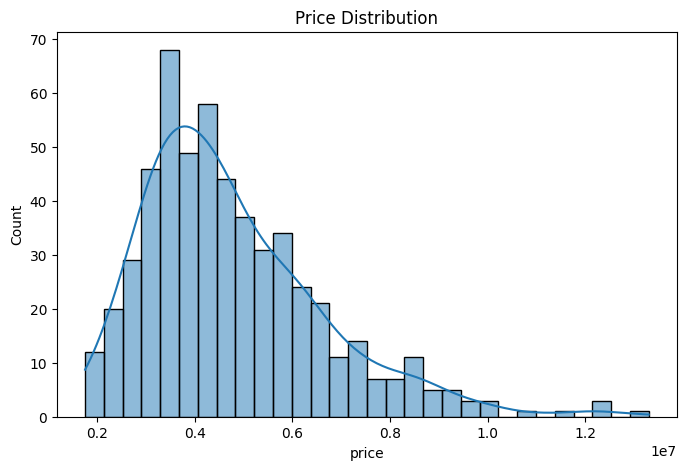

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=30, kde=True)
plt.title("Price Distribution")
plt.show()


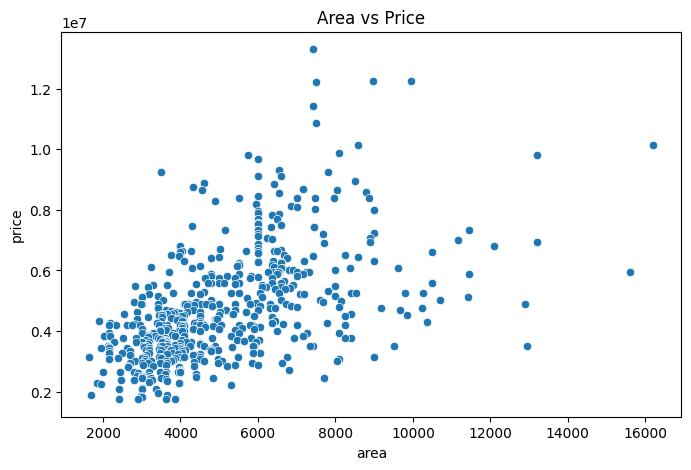

In [6]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='area', y='price', data=df)
plt.title("Area vs Price")
plt.show()


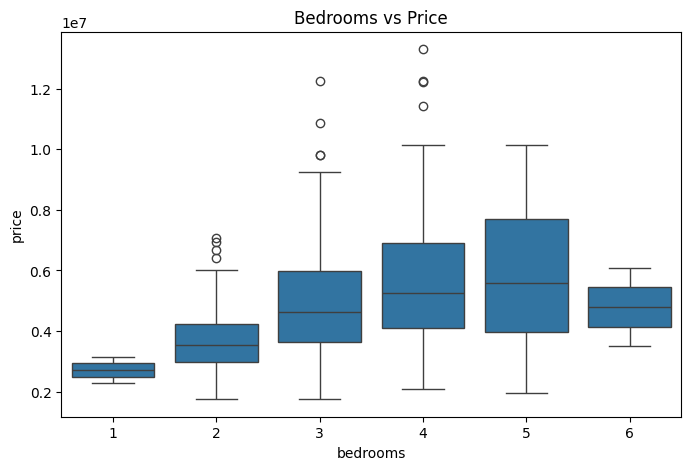

In [7]:
plt.figure(figsize=(8,5))
sns.boxplot(x='bedrooms', y='price', data=df)
plt.title("Bedrooms vs Price")
plt.show()


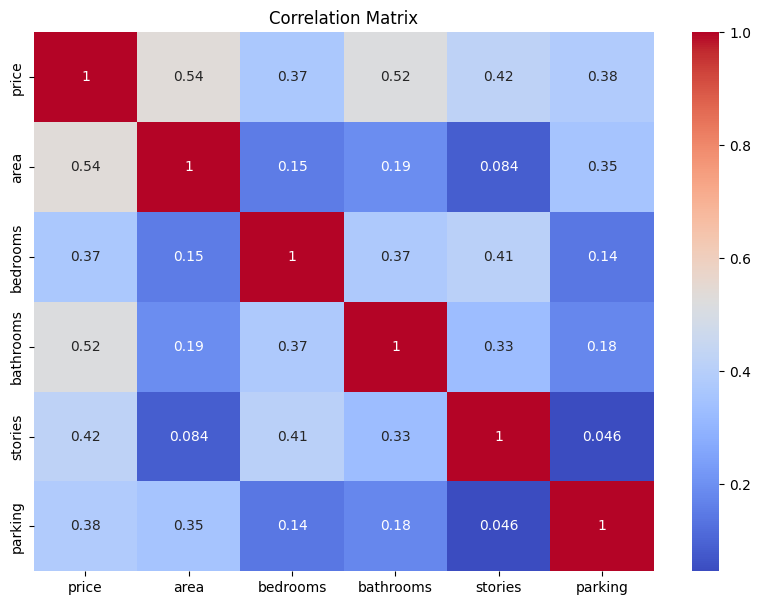

In [8]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


In [9]:
# Numerical scaling
num_transformer = StandardScaler()

# Categorical encoding
cat_transformer = OneHotEncoder(drop='first')

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ]
)

print("Preprocessing pipeline ready!")


Preprocessing pipeline ready!


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)


Train shape: (436, 12)
Test shape : (109, 12)


In [11]:
lr_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

print("Linear Regression model trained!")


Linear Regression model trained!


In [12]:
rf_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

print("Random Forest model trained!")


Random Forest model trained!


In [13]:
# Predictions from both models
y_pred_lr = lr_pipeline.predict(X_test)
y_pred_rf = rf_pipeline.predict(X_test)

print("Predictions generated successfully!")


Predictions generated successfully!


In [14]:
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    print("="*50)
    print(f"{name}")
    print("="*50)
    print(f"MAE  : ₹{mae:,.0f}")
    print(f"RMSE : ₹{rmse:,.0f}")

    return mae, rmse


In [15]:
mae_lr, rmse_lr = evaluate_model("Linear Regression", y_test, y_pred_lr)
mae_rf, rmse_rf = evaluate_model("Random Forest", y_test, y_pred_rf)


Linear Regression
MAE  : ₹970,043
RMSE : ₹1,324,507
Random Forest
MAE  : ₹1,015,869
RMSE : ₹1,398,418


In [16]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae_lr, mae_rf],
    "RMSE": [rmse_lr, rmse_rf]
})

results.set_index("Model", inplace=True)
print(results)


                            MAE          RMSE
Model                                        
Linear Regression  9.700434e+05  1.324507e+06
Random Forest      1.015869e+06  1.398418e+06


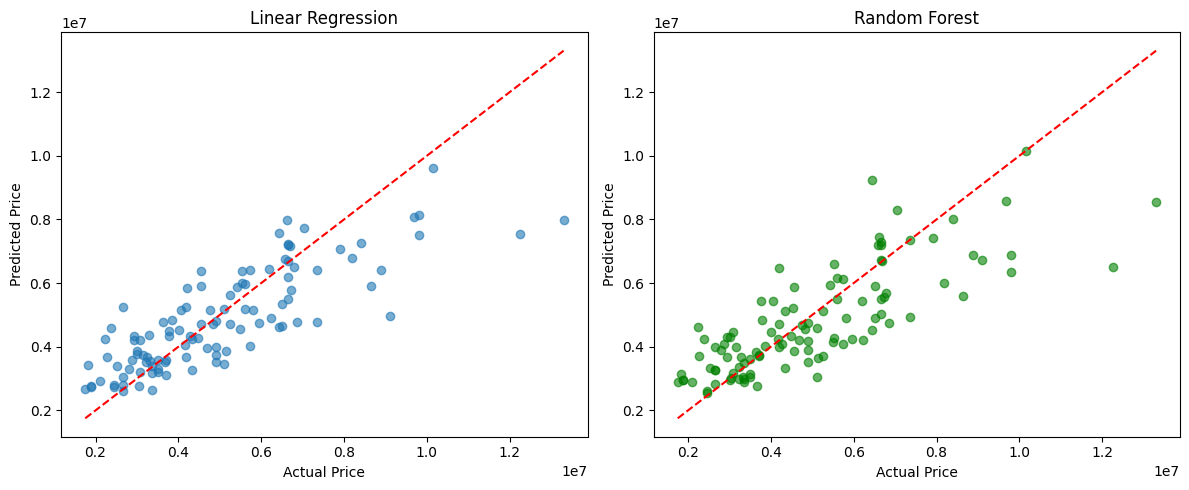

In [17]:
plt.figure(figsize=(12,5))

# Linear Regression
plt.subplot(1,2,1)
plt.scatter(y_test, y_pred_lr, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.title("Linear Regression")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

# Random Forest
plt.subplot(1,2,2)
plt.scatter(y_test, y_pred_rf, alpha=0.6, color='green')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.title("Random Forest")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.tight_layout()
plt.show()


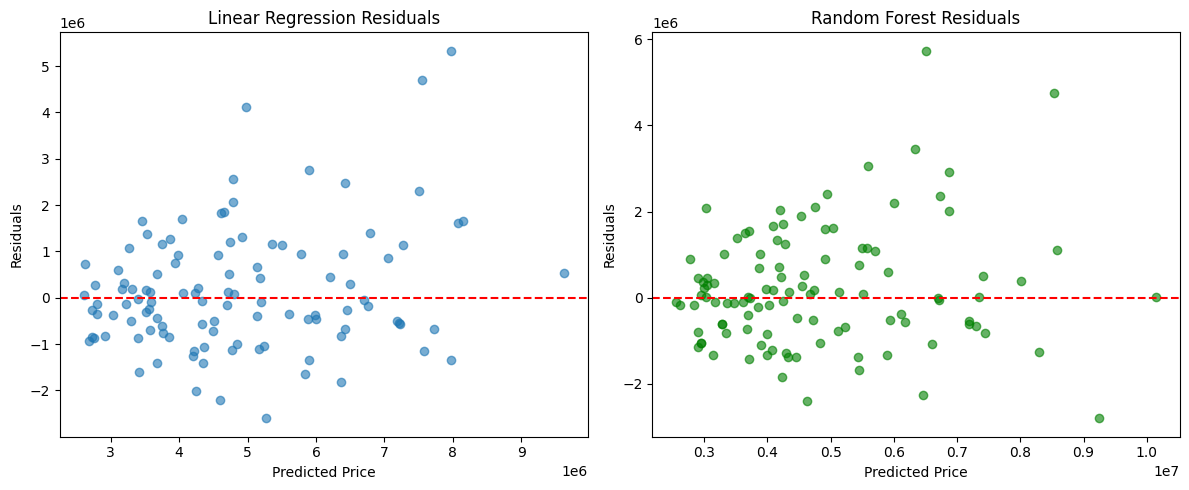

In [18]:
# Residuals
res_lr = y_test - y_pred_lr
res_rf = y_test - y_pred_rf

plt.figure(figsize=(12,5))

# Linear Regression Residuals
plt.subplot(1,2,1)
plt.scatter(y_pred_lr, res_lr, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title("Linear Regression Residuals")
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")

# Random Forest Residuals
plt.subplot(1,2,2)
plt.scatter(y_pred_rf, res_rf, alpha=0.6, color='green')
plt.axhline(0, color='red', linestyle='--')
plt.title("Random Forest Residuals")
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")

plt.tight_layout()
plt.show()


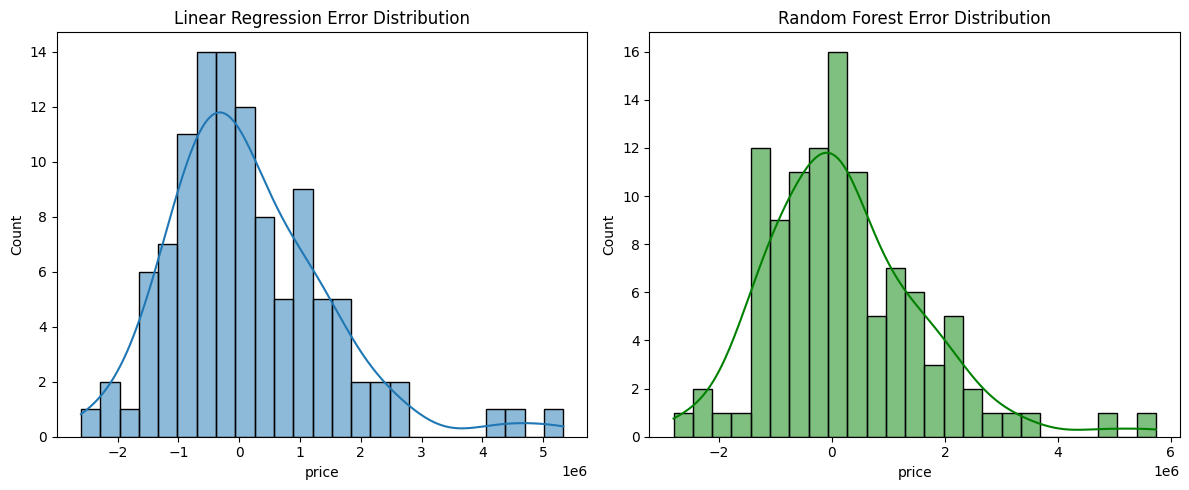

In [19]:
plt.figure(figsize=(12,5))

# LR Errors
plt.subplot(1,2,1)
sns.histplot(res_lr, bins=25, kde=True)
plt.title("Linear Regression Error Distribution")

# RF Errors
plt.subplot(1,2,2)
sns.histplot(res_rf, bins=25, kde=True, color='green')
plt.title("Random Forest Error Distribution")

plt.tight_layout()
plt.show()


In [20]:
# Get feature names after OneHotEncoding
ohe = rf_pipeline.named_steps['preprocessing'].named_transformers_['cat']
encoded_cat_features = ohe.get_feature_names_out(cat_cols)

all_features = num_cols + list(encoded_cat_features)

# Extract importance
importances = rf_pipeline.named_steps['model'].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": all_features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feature_importance.head(10))


                         Feature  Importance
0                           area    0.469477
2                      bathrooms    0.154334
9            airconditioning_yes    0.061149
4                        parking    0.056472
3                        stories    0.056223
1                       bedrooms    0.046936
12  furnishingstatus_unfurnished    0.037079
7                   basement_yes    0.032316
10                  prefarea_yes    0.028315
8            hotwaterheating_yes    0.018441


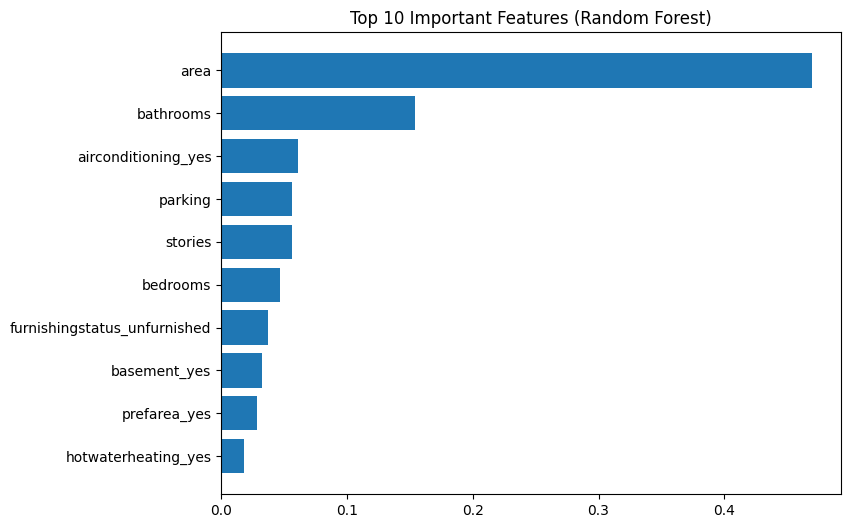

In [21]:
plt.figure(figsize=(8,6))

top_features = feature_importance.head(10)

plt.barh(top_features['Feature'], top_features['Importance'])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features (Random Forest)")

plt.show()
